In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

import numpy as np
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/abalone.csv")
df.head
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [ ]:
df=df.drop("id", axis =1)
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
# 성별 원 핫 인코딩
df = pd.get_dummies(df, columns=['Sex'], drop_first=False)

In [ ]:
df.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_F,Sex_I,Sex_M,AgeClass
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,False,True,2
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,False,True,0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,True,False,False,1
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,False,True,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,False,True,False,0


In [ ]:
# Rings → 3-class 분류 레이블 생성
# 연속적 값을 분류로 학습하기 위해서 구간별로 레이블 생성
def rings_to_class(r):
    if r <= 8:    return 0  # Young
    elif r <= 10: return 1  # Middle
    else:         return 2  # Old

df['AgeClass'] = df['Rings'].apply(rings_to_class)
print('클래스 분포:')
print(df['AgeClass'].value_counts().sort_index())
print('Young(0) / Middle(1) / Old(2)')

클래스 분포:
AgeClass
0    1407
1    1323
2    1447
Name: count, dtype: int64
Young(0) / Middle(1) / Old(2)


In [ ]:
X = df.drop(columns=['Rings', 'AgeClass'])

In [ ]:
y = df['AgeClass'].values

In [ ]:
print('X shape:', X.shape)
print('y shape:', y.shape)
print('특성 목록:', list(X.columns))

X shape: (4177, 10)
y shape: (4177,)
특성 목록: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Sex_F', 'Sex_I', 'Sex_M']


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
#스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [ ]:
import jax
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

input_dim = X_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    #rings를 클래스분포 0, 1, 2인 1차원정수배열로 했으므로 sparse 로 원핫처럼 처리
    metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,571 (21.76 KB)

 Trainable params: 5,315 (20.76 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
#earlystopping 적용
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5529 - loss: 1.0659 - val_accuracy: 0.6443 - val_loss: 0.8082 - learning_rate: 0.0010
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6107 - loss: 0.9056 - val_accuracy: 0.6507 - val_loss: 0.7568 - learning_rate: 0.0010
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6141 - loss: 0.8459 - val_accuracy: 0.6667 - val_loss: 0.7246 - learning_rate: 0.0010
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6333 - loss: 0.7965 - val_accuracy: 0.6938 - val_loss: 0.6967 - learning_rate: 0.0010
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6432 - loss: 0.7650 - val_accuracy: 0.6922 - val_loss: 0.6906 - learning_rate: 0.0010
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6483 - loss: 0.7516 - val_accuracy: 0.6970 - val_loss: 0.6749 - learning_rate: 0.0010
Epoch 7/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6476 - loss: 0.7345 - val_ac

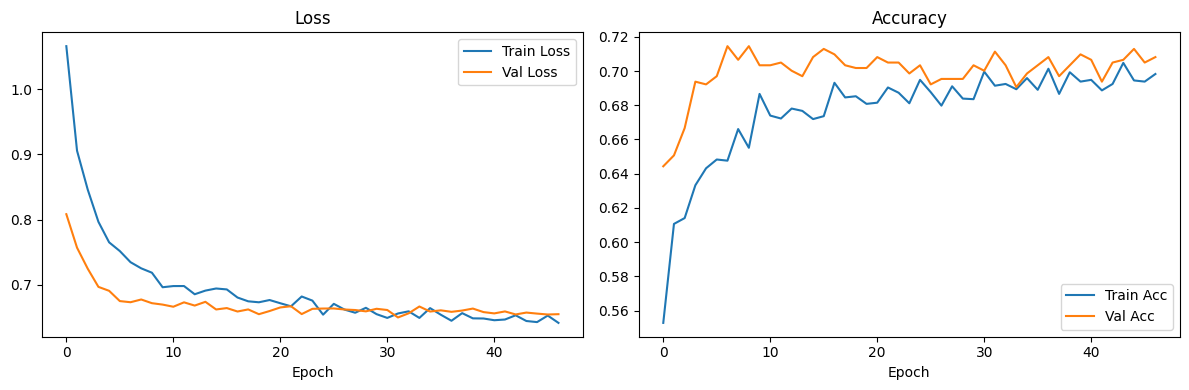

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

y_pred = np.argmax(model.predict(X_test), axis=1)

class_names = ['Young (≤8)', 'Middle (9-11)', 'Old (≥12)']

print(classification_report(y_test, y_pred, target_names=class_names))

Test Loss    : 0.6399
Test Accuracy: 0.7081
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
               precision    recall  f1-score   support

   Young (≤8)       0.80      0.74      0.77       133
Middle (9-11)       0.67      0.72      0.70       285
    Old (≥12)       0.70      0.67      0.68       209

     accuracy                           0.71       627
    macro avg       0.73      0.71      0.72       627
 weighted avg       0.71      0.71      0.71       627



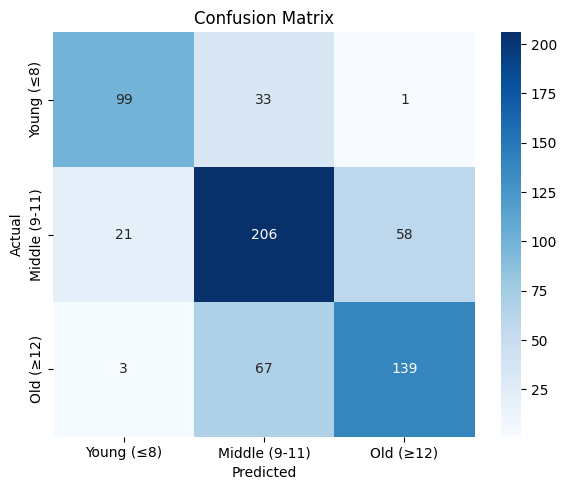

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()